# BMW Cars Dataset Analysis - Regression Study

In this project, we analyze a dataset containing detailed information about BMW vehicle listings. The dataset includes 10,781 records and 9 variables, describing characteristics such as model, year of manufacture, selling price, transmission type, mileage, fuel type, road tax, engine size, and fuel economy (mpg).

The objective of this study is to solve a regression problem by predicting the selling price of a vehicle based on its technical and descriptive features. The main path that is to follow will include:  <br>
-> EDA with visualizations <br>
-> building and comparing, tuning **classical ML models** as Linear Regression, Decision Trees, XGBoost, Random Forest <br>
-> building and comparing **Neural Network** architectures <br>
-> applying hyperparameter tuning, cross-validation and regularization <br>
-> drawing conclusions <br>


Dataset can be found here: [bmw](https://www.kaggle.com/datasets/wardabilal/bmw-cars-dataset-analysis-with-visualizations)

# 📦Section 1 : Setup
Installing and importing all required libraries:
- pandas, numpy for data
- matplotlib, seaborn, plotly for visualizations
- scikit-learn for classical ML models and preprocessing
- tensorflow / keras for Neural Networks

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import subprocess

# Check if required packages are installed, install them if missing
def install_package(package):
    try:
        __import__(package)
    except ImportError:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])

install_package("pytorch-tabnet")
install_package("shap")

from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from tensorflow.keras import regularizers, layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import shap
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

Installing pytorch-tabnet...


# 📦 Section 2 : Data Loading
We will load our data via github.


In [2]:
def load_dataset(dataset_name: str) -> pd.DataFrame:
  datasets = {
      "bmw": {
          "url": "https://raw.githubusercontent.com/nlaprade/bmw-price-dashboard/master/data/bmw.csv"
      }
  }
  if dataset_name in datasets:
    url = datasets[dataset_name]["url"]
    return pd.read_csv(url)
  else:
    raise ValueError("Dataset not found.")

In [3]:
# Loading data into DataFrame

df = load_dataset("bmw")


# 📦Section 3 - EDA
Before building the model we must understand the structure of our data. In this section I will be dealing with duplicates, missing values, data types, correlations and grain.

In [4]:
# Displaying 5 top rows
df.head(5)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,5 Series,2014,11200,Automatic,67068,Diesel,125,57.6,2.0
1,6 Series,2018,27000,Automatic,14827,Petrol,145,42.8,2.0
2,5 Series,2016,16000,Automatic,62794,Diesel,160,51.4,3.0
3,1 Series,2017,12750,Automatic,26676,Diesel,145,72.4,1.5
4,7 Series,2014,14500,Automatic,39554,Diesel,160,50.4,3.0


In [5]:
print(f"Data shape: {df.shape[0]} rows x {df.shape[1]} columns")
print("-------")
print(f"Column dtypes: \n{df.dtypes}")
print("-------")
print(f"Missing values: \n{df.isna().sum()}")
print("-------")
print(f"Duplicates: \n{df.duplicated().sum()}")

Data shape: 10781 rows x 9 columns
-------
Column dtypes: 
model            object
year              int64
price             int64
transmission     object
mileage           int64
fuelType         object
tax               int64
mpg             float64
engineSize      float64
dtype: object
-------
Missing values: 
model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64
-------
Duplicates: 
117


As we can see, our dataset has no missing values but it contains many duplicated values.

In [6]:
duplicates = df[df.duplicated(keep=False)]
duplicates = duplicates.sort_values(list(df.columns))
duplicates

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
7607,1 Series,2015,8490,Manual,50000,Petrol,125,50.4,1.6
7783,1 Series,2015,8490,Manual,50000,Petrol,125,50.4,1.6
5206,1 Series,2016,14652,Manual,9461,Diesel,20,70.6,1.5
5617,1 Series,2016,14652,Manual,9461,Diesel,20,70.6,1.5
2684,1 Series,2016,20990,Manual,10,Diesel,20,68.9,2.0
...,...,...,...,...,...,...,...,...,...
5883,X5,2019,51995,Semi-Auto,11,Diesel,145,37.7,3.0
5796,X5,2019,52990,Semi-Auto,10,Diesel,150,37.7,3.0
5817,X5,2019,52990,Semi-Auto,10,Diesel,150,37.7,3.0
2263,Z4,2020,35850,Semi-Auto,5,Petrol,145,37.2,2.0


In [7]:
# Dropping duplicates
df = df.drop_duplicates(keep="first")

In [8]:
df.describe().style.background_gradient(cmap='Purples').format('{:.2f}')

,year,price,mileage,tax,mpg,engineSize
count,10664.00,10664.00,10664.00,10664.00,10664.00,10664.00
mean,2017.06,22692.89,25710.98,131.60,56.48,2.17
std,2.35,11434.92,25146.63,61.61,31.47,0.55
min,1996.00,1200.00,1.00,0.00,5.50,0.00
25%,2016.00,14897.00,5665.75,135.00,45.60,2.00
50%,2017.00,20261.50,18783.00,145.00,53.30,2.00
75%,2019.00,27890.00,38436.50,145.00,62.80,2.00
max,2020.00,123456.00,214000.00,580.00,470.80,6.60


The dataset shows significant variability in the target variable (price), with values ranging from approximately 1,200 to over 120,000. This indicates that vehicle prices are influenced by multiple factors and are not constant across observations.

The data also reveals substantial variation in key features such as mileage and engine size, which are expected to have a strong impact on pricing. For example, mileage ranges from very low values to over 200,000, suggesting large differences in vehicle condition.

Additionally, the year of manufacture is relatively concentrated around recent years, which may influence price through vehicle age. Fuel economy (mpg) and tax also show noticeable variability, potentially contributing to price differences.

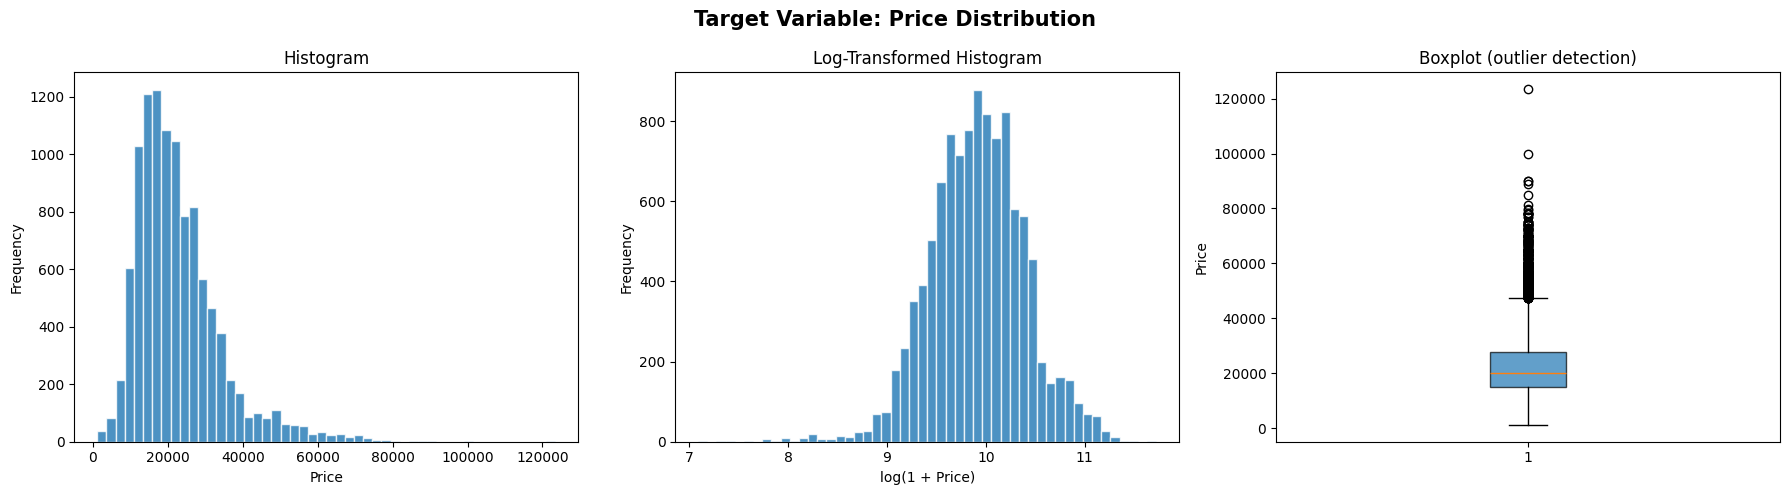

In [9]:
# Target Variable Distribution

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Target Variable: Price Distribution', fontsize=15, fontweight='bold')

# Histogram
axes[0].hist(df['price'], bins=50, edgecolor='white', alpha=0.8)
axes[0].set_title('Histogram')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Frequency')

# Log-transformed
log_price = np.log1p(df['price'])
axes[1].hist(log_price, bins=50, edgecolor='white', alpha=0.8)
axes[1].set_title('Log-Transformed Histogram')
axes[1].set_xlabel('log(1 + Price)')
axes[1].set_ylabel('Frequency')

# Box plot
axes[2].boxplot(df['price'], patch_artist=True,
                boxprops=dict(alpha=0.7))
axes[2].set_title('Boxplot (outlier detection)')
axes[2].set_ylabel('Price')

plt.tight_layout()
plt.show()


The distribution of the target variable (price) is strongly right-skewed, indicating that most vehicles are concentrated in the lower price range, while a smaller number of high-value cars create a long tail in the distribution.
Applying a logarithmic transformation significantly reduces skewness and results in a more symmetric distribution, which is beneficial for regression models that assume normality. We may also see the presence of many high-price outliers.

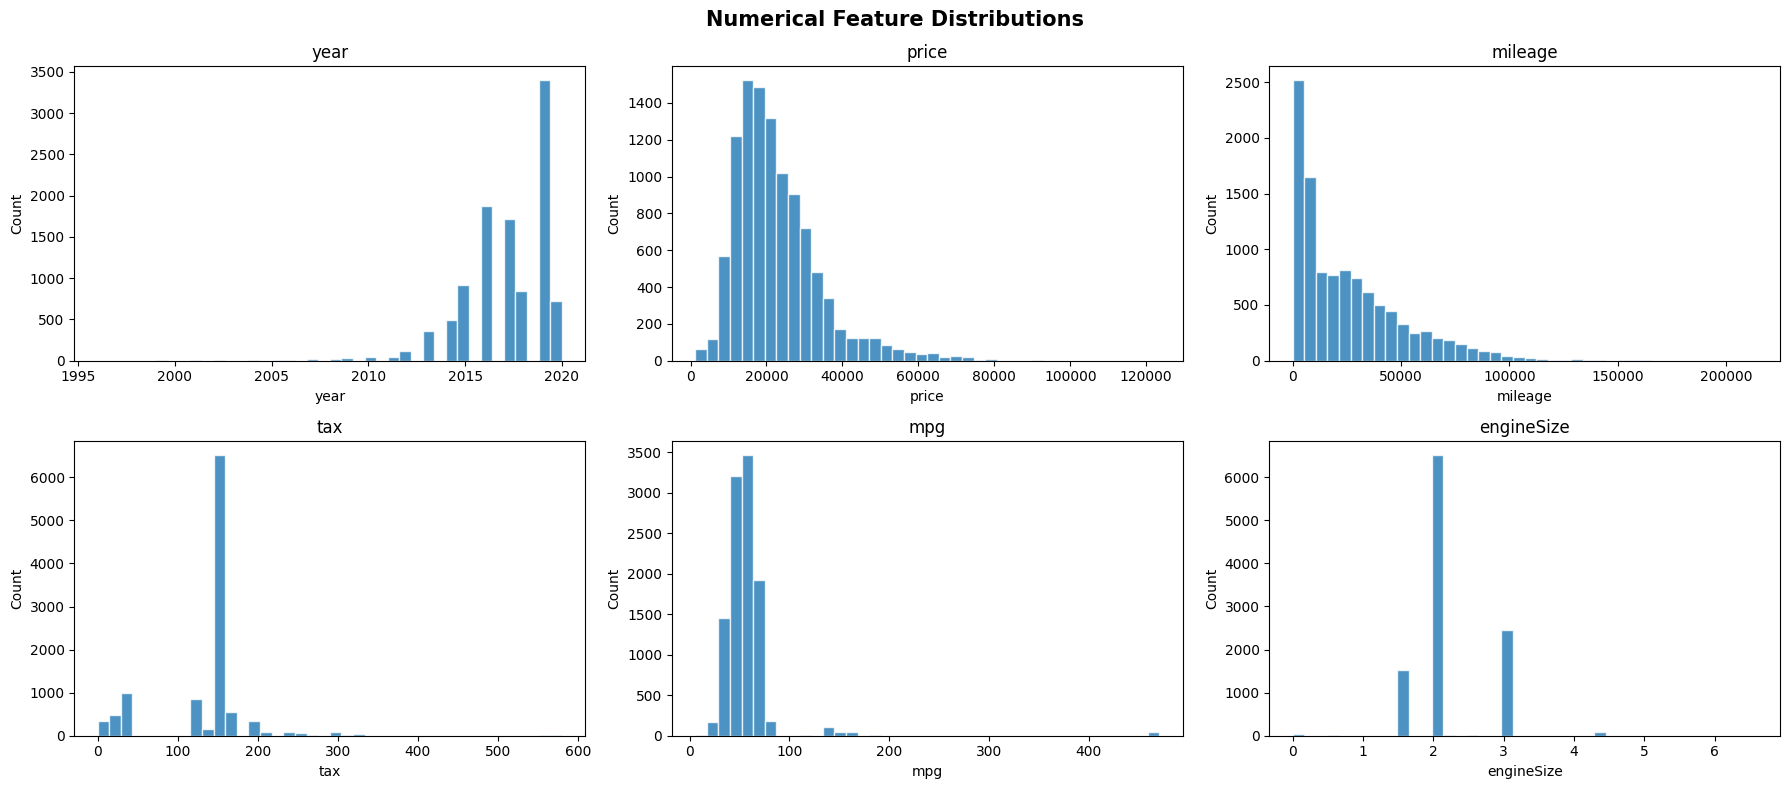

In [10]:
# Let's check Numerical Distributions
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c != 'Price']

n_cols_plot = 3
n_rows_plot = (len(num_cols) + n_cols_plot - 1) // n_cols_plot
fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(18, 4 * n_rows_plot))
fig.suptitle('Numerical Feature Distributions', fontsize=15, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=40,
                 edgecolor='white', alpha=0.8)
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

- We may see diverse distributions, indicating varying levels of variability and data characteristics across variables
- The year variable is concentrated mostly between years: 2015-2020 suggesting that the dataset mainly contains newer vehicles, which may influence higher price levels
- Mileage shows right-skewed distribution with most vehicles having relatively low mileage and a few observations with very high values. This suggests that mileage is likely to be a key factor negatively affecting vehicle price
- Fuel economy (mpg) is mostly concentrated within a typical range, although some extreme values are present, which may represent outliers or special vehicle types
- Engine values are rather concentrated

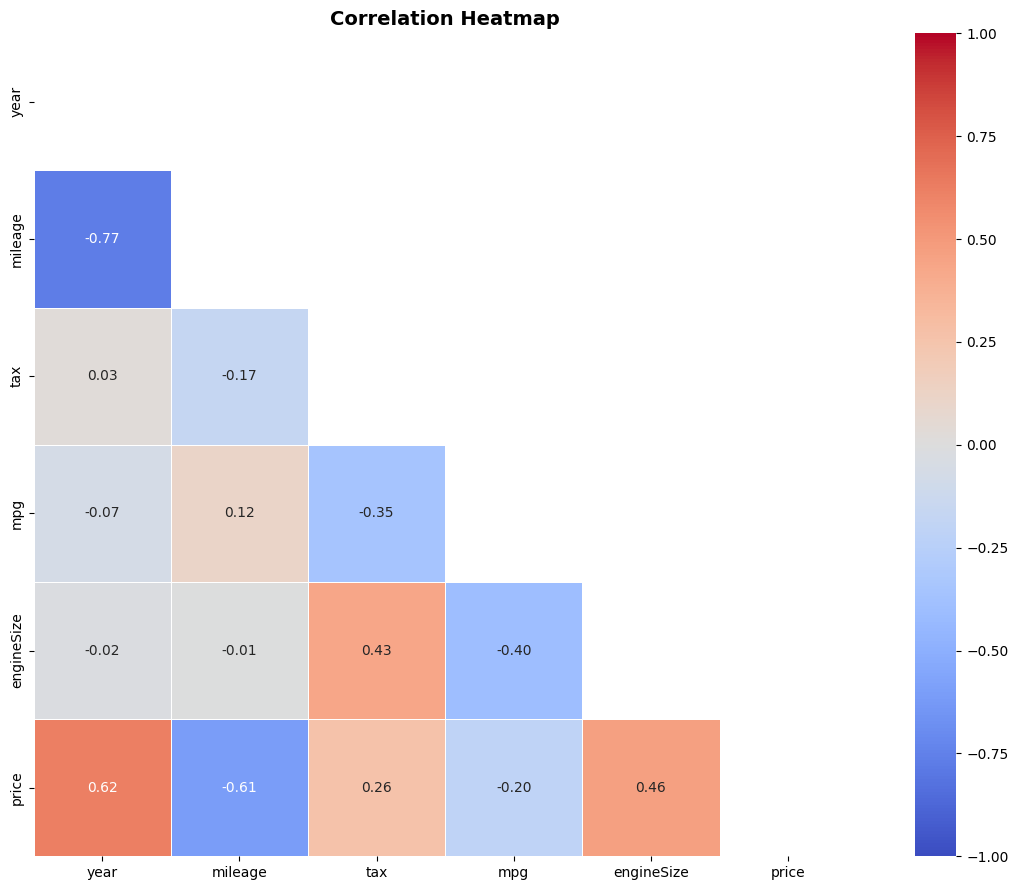

year          0.623754
mileage       0.605473
engineSize    0.461750
tax           0.264178
mpg           0.203986


In [11]:
# Correlation Heatmap

num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols = [c for c in num_cols if c != 'price']
corr_matrix = df[num_cols + ['price']].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 10})
ax.set_title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

target_corr = corr_matrix['price'].drop('price').abs().sort_values(ascending=False)
print(target_corr.to_string())

### Correlation Analysis

The correlation analysis reveals that there is a strong linear relationship between some features.

In particular, year and mileage show the highest correlations, indicating that newer vehicles tend to be more expensive, while higher mileage is associated with lower prices. Engine size also demonstrates a moderate positive correlation with price, suggesting that more powerful vehicles are generally more valuable.

Other variables such as tax and fuel economy (mpg) show weaker correlations, indicating a smaller direct influence on pricing.

We may now expect that both linear and non-linear models are about to give us competitive results.

# 📦 Section 4: Preprocessing and Feature Engineering

**Approach**:
- I am about to test both raw price and log1p(price) - log transformation often helps tree and neural models by reducing skewness
- Scaling: StandardScaler will be used for numerical features (critical for neural networks and distance-based models)
- Train / Validation / Test split: 70% / 15% / 15%

In [12]:
# Feature Engineering

# Let's make a copy to ensure that we are not messing the original dataframe
df_copy = df.copy()
df_copy.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize'],
      dtype='object')

In [13]:
# Car's age
df_copy['car_age'] = 2026 - df_copy['year']

In [14]:
# log mileage since our results are slightly skewed
df_copy['log_mileage'] = np.log1p(df_copy['mileage'])

In [15]:
# Price per engine size
df_copy['log_mileage'] = np.log1p(df_copy['mileage'])

In [16]:
# engine grouping
# df_copy['engine_category'] = pd.cut(df_copy['engineSize'],
#                               bins=[0, 1.6, 2.5, 4, 10],
#                               labels=[0, 1, 2, 3])

In [17]:
df_copy.dtypes

,0
model,object
year,int64
price,int64
transmission,object
mileage,int64
fuelType,object
tax,int64
mpg,float64
engineSize,float64
car_age,int64


In [18]:
# fuel efficiency ratio
df_copy['efficiency'] = df_copy['mpg'] / df_copy['engineSize']

In [19]:
# log target
df_copy['log_price'] = np.log1p(df_copy['price'])

In [20]:
df_copy.head(3)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,car_age,log_mileage,efficiency,log_price
0,5 Series,2014,11200,Automatic,67068,Diesel,125,57.6,2.0,12,11.113477,28.800000,9.323758
1,6 Series,2018,27000,Automatic,14827,Petrol,145,42.8,2.0,8,9.604273,21.400000,10.203629
2,5 Series,2016,16000,Automatic,62794,Diesel,160,51.4,3.0,10,11.047631,17.133333,9.680406


In [21]:
# Object values -> dummies
obj_cols = df_copy.select_dtypes(include='object').columns
df_copy = pd.get_dummies(df_copy, columns=obj_cols, drop_first=True)

In [22]:
df_copy.head(2)

,year,price,mileage,tax,mpg,engineSize,car_age,log_mileage,efficiency,log_price,...,model_ Z3,model_ Z4,model_ i3,model_ i8,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,2014,11200,67068,125,57.6,2.0,12,11.113477,28.8,9.323758,...,False,False,False,False,False,False,False,False,False,False
1,2018,27000,14827,145,42.8,2.0,8,9.604273,21.4,10.203629,...,False,False,False,False,False,False,False,False,False,True


In [23]:
# features / target
TARGET = "price"
LOG_TARGET = "log_price"
# X = df_copy.drop(columns=[TARGET, LOG_TARGET]).astype(float)
X = df_copy.drop(columns=[TARGET, LOG_TARGET])
y = df_copy[TARGET].astype(float)

# split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1765, random_state=42)

# clean
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_val   = X_val.replace([np.inf, -np.inf], np.nan)
X_test  = X_test.replace([np.inf, -np.inf], np.nan)

X_train = X_train.fillna(X_train.median())
X_val   = X_val.fillna(X_train.median())
X_test  = X_test.fillna(X_train.median())

# scaling
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

# target
y_train_log = np.log1p(y_train)
y_val_log   = np.log1p(y_val)
y_test_log  = np.log1p(y_test)

# 📦 Section 5: Basic ML Models
I am about to start with classical ML models to establish strong baseline and to check how our dataset responds with simple ML solutions.

**MODELS**:
1. Linear Regression (with and without regularization: Lasso)
2. Decision Tree Regressor
3. Random Forest Regressor
4. XGBoost Regressor

❗All models are evaluated using 5-fold cross-validation(CV) on the training set, then final metrics on the held-out test set.

In [24]:
# evaluation function helper
results = {}

def evaluate_model(name, model, X_train, y_train, X_test, y_test,
                   cv_folds=5, log_target=False):
    """Fit, cross-validate, and evaluate a model. Returns dict of metrics."""
    # cross validation
    kf = KFold(n_splits=cv_folds, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_train, y_train, cv=kf,
                                scoring='neg_root_mean_squared_error')
    cv_rmse = -cv_scores

    # fit on full training set
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test) # prediction

    if log_target:
        y_pred = np.expm1(y_pred)
        y_test   = np.expm1(y_test)

    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    test_mae  = mean_absolute_error(y_test, y_pred)
    test_r2   = r2_score(y_test, y_pred)

    print(f'model: {name}')
    print(f'  CV RMSE:   {cv_rmse.mean():.3f} +- {cv_rmse.std():.3f}')
    print(f'  Test RMSE: {test_rmse:.3f}')
    print(f'  test MAE:  {test_mae:.3f}')
    print(f'  Test R*R:   {test_r2:.4f}\n')
    print(f'  Overfitting gap: {abs(cv_rmse.mean() - test_rmse):.3f}')

    results[name] = {
        'cv_rmse_mean': cv_rmse.mean(),
        'cv_rmse_std':  cv_rmse.std(),
        'test_rmse':    test_rmse,
        'test_mae':     test_mae,
        'test_r2':      test_r2
        # 'y_pred':       y_pred too long
    }
    return results[name]


In [25]:
#linear models
evaluate_model('Linear Regression',LinearRegression(), X_train_s, y_train, X_test_s, y_test)
evaluate_model('Lasso (alpha=1.0)', Lasso(alpha=1.0, max_iter=5000), X_train_s, y_train, X_test_s, y_test)

model: Linear Regression
  CV RMSE:   4075.722 +- 491.507
  Test RMSE: 4175.671
  test MAE:  2708.888
  Test R*R:   0.8589

  Overfitting gap: 99.949
model: Lasso (alpha=1.0)
  CV RMSE:   4075.765 +- 491.473
  Test RMSE: 4175.972
  test MAE:  2709.667
  Test R*R:   0.8589

  Overfitting gap: 100.207


{'cv_rmse_mean': np.float64(4075.7648498605313),
 'cv_rmse_std': np.float64(491.472888569802),
 'test_rmse': np.float64(4175.971943736629),
 'test_mae': 2709.666734428401,
 'test_r2': 0.8589103241895415}

Firstly two basic models were considered: basic Linear Regression and Lasso Regression with regularization alpha = 0.1. Both models achieved very similar results - for both models R*R score is approximately 0.859 which states that around 85.9% of the variance in car prices is explained by the models. Overall, the results suggest that the dataset is well-behaved and does not strongly benefit from L1 regularization.

In [26]:
# Decision Tree with different depth in second example since depth limit prevents overfitting
evaluate_model('Decision Tree (default)',
               DecisionTreeRegressor(random_state=42),
               X_train, y_train, X_test, y_test)

evaluate_model('Decision Tree with max_depth=8',
               DecisionTreeRegressor(max_depth=8, min_samples_leaf=10, random_state=42),
               X_train, y_train, X_test, y_test)


model: Decision Tree (default)
  CV RMSE:   3560.576 +- 636.372
  Test RMSE: 2998.093
  test MAE:  1953.602
  Test R*R:   0.9273

  Overfitting gap: 562.483
model: Decision Tree with max_depth=8
  CV RMSE:   4086.181 +- 397.195
  Test RMSE: 3645.949
  test MAE:  2284.906
  Test R*R:   0.8925

  Overfitting gap: 440.232


{'cv_rmse_mean': np.float64(4086.180595414541),
 'cv_rmse_std': np.float64(397.19453971985837),
 'test_rmse': np.float64(3645.948611050778),
 'test_mae': 2284.905604723366,
 'test_r2': 0.892452287559377}

The default Decision Tree achieved significantly better performance than linear models, with a test RMSE of 2998.09 and R*R of 0.927, indicating strong predictive capability. However, the difference between cross-validation and test results suggests some variability across data splits.

The constrained model showed **worse** performance (RMSE = 3645.95, R*R = 0.892), indicating underfitting due to reduced model complexity, despite a smaller performance gap.

Overall, the results suggest that tree-based models better capture nonlinear relationships in the data, but require careful tuning to balance bias and variance.

In [27]:
# Random Forest with 100 and 200 trees
evaluate_model('Random Forest 100 trees',
               RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
               X_train, y_train, X_test, y_test)

evaluate_model('Random Forest 200 trees',
               RandomForestRegressor(n_estimators=200, max_depth=15,
                                     min_samples_leaf=5, random_state=42, n_jobs=-1),
               X_train, y_train, X_test, y_test)

model: Random Forest 100 trees
  CV RMSE:   2773.630 +- 558.304
  Test RMSE: 2433.922
  test MAE:  1533.771
  Test R*R:   0.9521

  Overfitting gap: 339.709
model: Random Forest 200 trees
  CV RMSE:   3218.179 +- 485.993
  Test RMSE: 2937.277
  test MAE:  1658.026
  Test R*R:   0.9302

  Overfitting gap: 280.902


{'cv_rmse_mean': np.float64(3218.179056478464),
 'cv_rmse_std': np.float64(485.992887973212),
 'test_rmse': np.float64(2937.2768543066604),
 'test_mae': 1658.0260822325065,
 'test_r2': 0.9301976800130305}

Random Forest models were evaluated with different configurations to predict car prices.

The model with 100 trees achieved the best performance, with a test RMSE of 2433.92, MAE of 1533.77, and R*R of 0.952, significantly outperforming both linear models and a single Decision Tree. This indicates strong predictive power and effective handling of nonlinear relationships.

In contrast, the more constrained model with 200 trees (max_depth = 15, min_samples_leaf = 5) showed worse performance (RMSE = 2937.28, R*R = 0.930), suggesting that the imposed limitations reduced model flexibility and led to underfitting, despite a slightly smaller overfitting gap.

Overall, the results confirm that ensemble methods such as Random Forest substantially improve performance, while excessive regularization can degrade model accuracy. Let's add some tests.

In [28]:
# More RandomForest Results
for n in [50, 100, 200]:
    evaluate_model(f'Random Forest ({n} trees)',
                   RandomForestRegressor(n_estimators=n, random_state=42, n_jobs=-1),
                   X_train, y_train, X_test, y_test)

model: Random Forest (50 trees)
  CV RMSE:   2784.664 +- 563.199
  Test RMSE: 2430.749
  test MAE:  1542.795
  Test R*R:   0.9522

  Overfitting gap: 353.915
model: Random Forest (100 trees)
  CV RMSE:   2773.630 +- 558.304
  Test RMSE: 2433.922
  test MAE:  1533.771
  Test R*R:   0.9521

  Overfitting gap: 339.709
model: Random Forest (200 trees)
  CV RMSE:   2770.514 +- 560.857
  Test RMSE: 2457.461
  test MAE:  1536.873
  Test R*R:   0.9511

  Overfitting gap: 313.052


The best results turned out to be including 50 trees indicating that the more is not always the better.

In [29]:
# XGBoost 2 versions
evaluate_model('XGBoost (default)',
               xgb.XGBRegressor(objective='reg:squarederror',
                                random_state=42, verbosity=0),
               X_train, y_train, X_test, y_test)

evaluate_model('XGBoost (tuned)',
               xgb.XGBRegressor(objective='reg:squarederror',
                                n_estimators=300, max_depth=6,
                                learning_rate=0.05, subsample=0.8,
                                colsample_bytree=0.8, reg_alpha=0.1,
                                reg_lambda=1.0, random_state=42, verbosity=0),
               X_train, y_train, X_test, y_test)

model: XGBoost (default)
  CV RMSE:   2757.178 +- 556.950
  Test RMSE: 2440.976
  test MAE:  1499.652
  Test R*R:   0.9518

  Overfitting gap: 316.202
model: XGBoost (tuned)
  CV RMSE:   2666.874 +- 561.563
  Test RMSE: 2312.608
  test MAE:  1486.422
  Test R*R:   0.9567

  Overfitting gap: 354.267


{'cv_rmse_mean': np.float64(2666.874392411858),
 'cv_rmse_std': np.float64(561.5630407203417),
 'test_rmse': np.float64(2312.6076341355374),
 'test_mae': 1486.4215983581544,
 'test_r2': 0.9567302883480461}

Compared to the default model, tuning hyperparameters such as learning rate, tree depth, and regularization led to a noticeable improvement in predictive accuracy. Although the overfitting gap slightly increased, the model maintains good generalization performance. The results are - once again - truly satisfying. The tuned XGBoost model achieved the best overall performance, with a test RMSE of 2312.61, MAE of 1486.42, and R*R of 0.957, outperforming all previously tested models, including Random Forest. This demonstrates the effectiveness of gradient boosting in capturing complex nonlinear relationships.

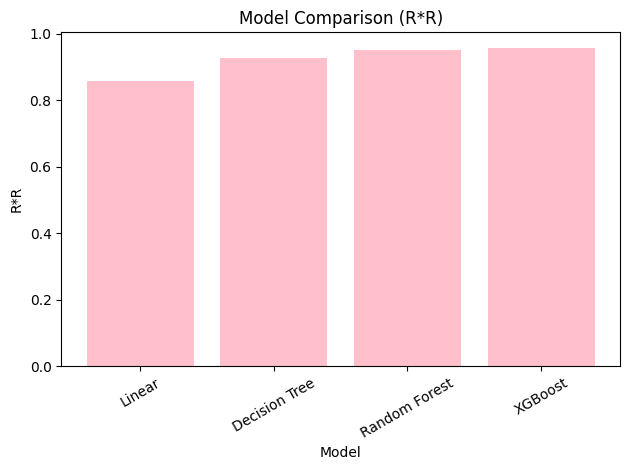

In [30]:
# RESULTS OVERALL
import matplotlib.pyplot as plt

models = ['Linear', 'Decision Tree', 'Random Forest', 'XGBoost']
rmse = [4175, 2998, 2433, 2313]
r2 = [0.859, 0.927, 0.952, 0.957]

plt.figure()
plt.bar(models, r2, color="pink")
plt.title('Model Comparison (R*R)')
plt.xlabel('Model')
plt.ylabel('R*R')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

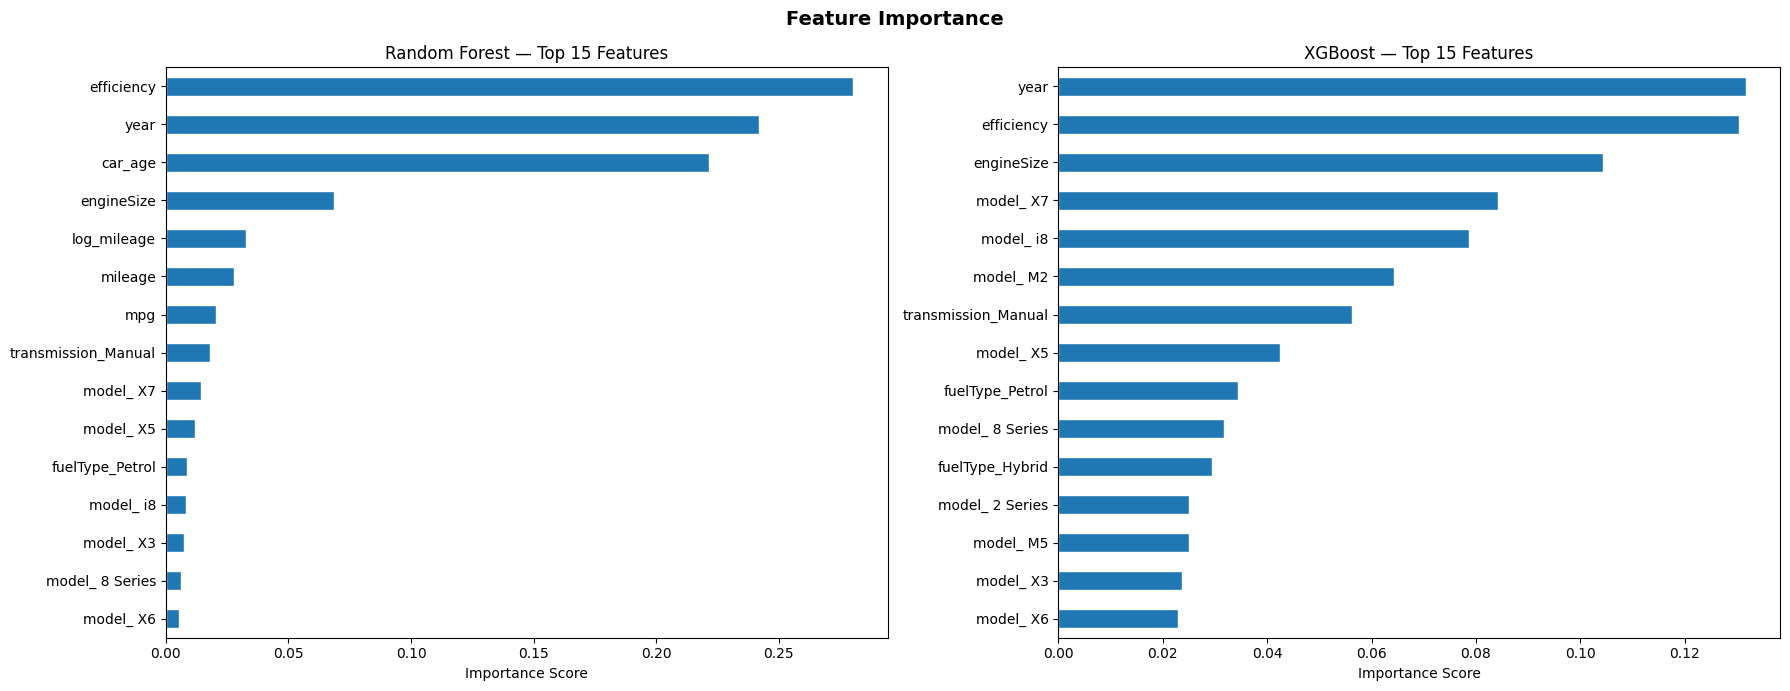

In [31]:
# Random Forest & XGBoost
rf_model = RandomForestRegressor(n_estimators=200, max_depth=15,
                                  min_samples_leaf=5, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=300,
                               max_depth=6, learning_rate=0.05, random_state=42, verbosity=0)
xgb_model.fit(X_train, y_train)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Feature Importance', fontsize=14, fontweight='bold')

for ax, model, name in [(axes[0], rf_model, 'Random Forest'),
                         (axes[1], xgb_model, 'XGBoost')]:
    importances = pd.Series(model.feature_importances_,
                             index=X_train.columns).sort_values(ascending=True).tail(15)
    importances.plot(kind='barh', ax=ax, edgecolor='white')
    ax.set_title(f'{name} — Top 15 Features', fontsize=12)
    ax.set_xlabel('Importance Score')

plt.tight_layout()
plt.show()


Feature importance analysis reveals that variables such as efficiency, year, and car age are the most influential predictors of car prices. This indicates that both technical characteristics and temporal factors play a key role in determining vehicle value.

# 📦 Section 6: Neural Networks Models
This is the main core of this notebook. I am about to experiment with a series of neural network architectures, progressively improving performance through:
| Experiment | Architecture | Key Technique |
|-----------|-------------|---------------|
| NN-1 | Shallow MLP (1 hidden layer) | Baseline NN |
| NN-2 | Medium MLP (3 hidden layers) | Deeper network |
| NN-3 | Regularized MLP (L2 + Dropout) | Prevent overfitting |
| NN-4 | Batch Normalization + Dropout | Stabilization |
| NN-5 | Optimized architecture + callbacks | Best performance |

**Metrics used:**
- RMSE- main metric
- MAE — robust to outliers
- R*R— explained variance

In [32]:
# First i will create helper function to process nn details
def plot_training_history(history, model_name, ax=None):
    """Plot training and validation loss curves"""
    show = ax is None
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(history.history['loss'], label='Train Loss', linewidth=2)
    ax.plot(history.history['val_loss'], label='Val Loss',
            linewidth=2, linestyle='--')
    ax.set_title(f'{model_name} — Training Curves', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss -mse')
    ax.legend()
    ax.grid(True, alpha=0.3)
    if show:
        plt.tight_layout()
        plt.show()

def evaluate_nn(name, model, X_te, y_te, history=None, plot=True):
    """Evaluate a Keras model on the test set."""
    y_pred_scaled = model.predict(X_te, verbose=0).ravel()
    y_pred = target_scaler.inverse_transform(y_pred_scaled.reshape(-1,1)).ravel()

    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    mae  = mean_absolute_error(y_te, y_pred)
    r2   = r2_score(y_te, y_pred)

    print(f'[{name}]')
    print(f'  Test RMSE: {rmse:.2f}')
    print(f'  Test MAE:  {mae:.2f}')
    print(f'  Test R*R:   {r2:.4f}\n')

    results[name] = {
        'cv_rmse_mean': None,
        'cv_rmse_std':  None,
        'test_rmse':    rmse,
        'test_mae':     mae,
        'test_r2':      r2,
        'y_pred':       y_pred,
        'history':      history
    }
    return results[name]

def get_callbacks(patience=15, name='model'):
    return [
        EarlyStopping(monitor='val_loss', patience=patience,
                      restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=patience//2, min_lr=1e-6, verbose=0)
    ]


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,545 (17.75 KB)

 Trainable params: 4,545 (17.75 KB)

 Non-trainable params: 0 (0.00 B)

None


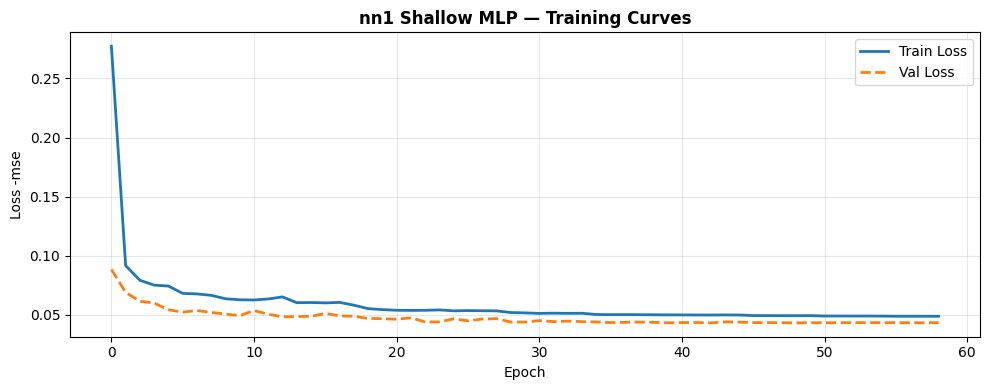

[nn1 shallow MLP]
  Test RMSE: 2753.48
  Test MAE:  1669.86
  Test R*R:   0.9387



In [33]:
# Our first neural network with following architecture:
"""
Architecture: input -> 64 -> output
  - 1 hidden layer, ReLU activation
  - Adam optimizer, MSE loss
  - No regularization
"""

target_scaler = StandardScaler()

y_train_nn = target_scaler.fit_transform(y_train.values.reshape(-1,1))
y_val_nn   = target_scaler.transform(y_val.values.reshape(-1,1))
y_test_nn  = target_scaler.transform(y_test.values.reshape(-1,1))

def build_nn1():
    model = Sequential([
        Dense(64, activation='relu', input_shape=(N_FEATURES,)),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(1e-3), loss='mse', metrics=['mae'])
    return model

N_FEATURES = X_train_s.shape[1]
nn1 = build_nn1()
print(nn1.summary())

history_nn1 = nn1.fit(
    X_train_s, y_train_nn,
    validation_data=(X_val_s, y_val_nn),
    epochs=200, batch_size=64,
    callbacks=get_callbacks(10),
    verbose=0
)

plot_training_history(history_nn1, 'nn1 Shallow MLP')
r1 = evaluate_nn('nn1 shallow MLP', nn1, X_test_s, y_test)

The neural network achieved a test RMSE of 2753.17 and R*R of 0.94, outperforming linear models but remaining slightly worse than tree-based ensemble methods such as Random Forest and XGBoost.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


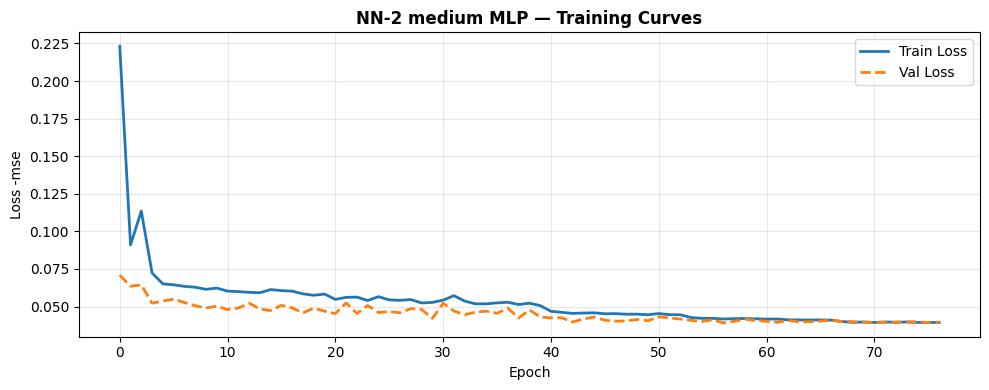

[NN-2 Medium MLP]
  Test RMSE: 2580.99
  Test MAE:  1578.93
  Test R*R:   0.9461



In [34]:
# nn- 3 hidden layers
"""
Architecture: Input -> 128 -> 64 -> 32 -> Output
Change from NN-1: +2 hidden layers, larger first layer
"""

def build_nn2():
    model = Sequential([
        Dense(128, activation='relu', input_shape=(N_FEATURES,)),
        Dense(64,  activation='relu'),
        Dense(32,  activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(1e-3), loss='mse', metrics=['mae'])
    return model

nn2 = build_nn2()
history_nn2 = nn2.fit(
    X_train_s, y_train_nn,
    validation_data=(X_val_s, y_val_nn),
    epochs=250, batch_size=64,
    callbacks=get_callbacks(20),
    verbose=0
)

plot_training_history(history_nn2, 'NN-2 medium MLP')
r2_ = evaluate_nn('NN-2 Medium MLP', nn2, X_test_s, y_test)


Increasing model complexity improves neural network performance, but it still does not surpass gradient boosting methods.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


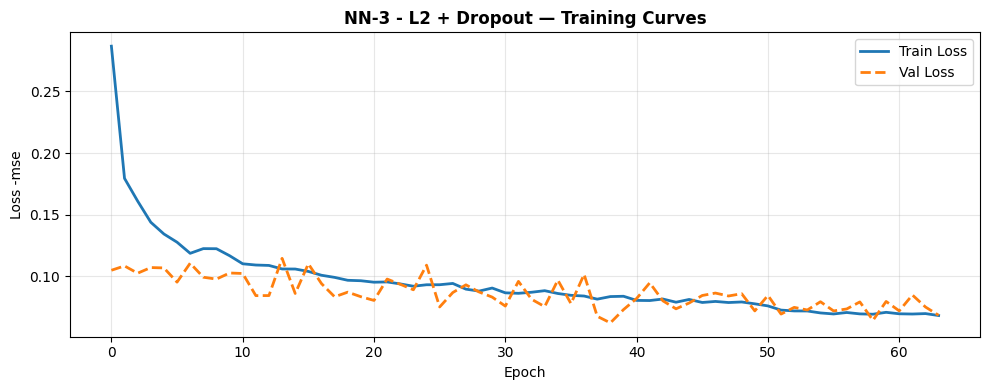

[NN-3: L2 + Dropout]
  Test RMSE: 2819.28
  Test MAE:  1770.83
  Test R*R:   0.9357



In [35]:
# NN-3: Regularized MLP as L2 + dropout
"""
Architecture: Input -> [256+L2] -> Dropout -> [128+L2] -> Dropout -> 64 → Output
"""

def build_nn4(l2_rate=1e-4, dropout=0.3):
    model = Sequential([
        Dense(256, activation='relu', input_shape=(N_FEATURES,),
              kernel_regularizer=regularizers.l2(l2_rate)),
        Dropout(dropout),
        Dense(128, activation='relu',
              kernel_regularizer=regularizers.l2(l2_rate)),
        Dropout(dropout),
        Dense(64, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(1e-3), loss='mse', metrics=['mae'])
    return model

nn4 = build_nn4()
history_nn4 = nn4.fit(
    X_train_s, y_train_nn,
    validation_data=(X_val_s, y_val_nn),
    epochs=300, batch_size=64,
    callbacks=get_callbacks(25),
    verbose=0
)

plot_training_history(history_nn4, 'NN-3 - L2 + Dropout')
r4 = evaluate_nn('NN-3: L2 + Dropout', nn4, X_test_s, y_test)


NN-3 with L2 regularization and Dropout achieves strong performance
(R² = 0.9357, RMSE = 2819), demonstrating that regularization
successfully prevents overfitting without sacrificing predictive power. The slight oscillation in validation loss is typical for smaller
validation sets and does not indicate instability.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


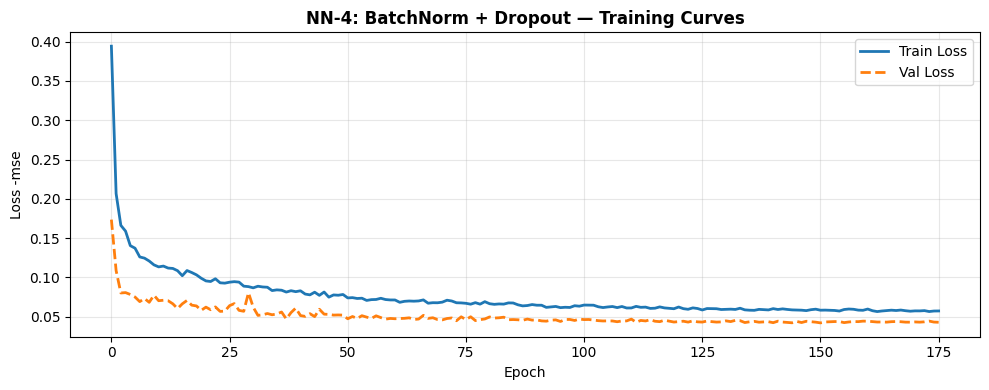

[NN-4: BatchNorm + Dropout]
  Test RMSE: 2598.83
  Test MAE:  1584.43
  Test R*R:   0.9454



In [36]:
# Batch Normalization
# from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
"""
Architecture: Input -> dense -> BatchNorm -> ReLU -> Dropout -> Output
"""

def build_nn5():
    model = Sequential([
        Dense(256, input_shape=(N_FEATURES,)),
        BatchNormalization(),
        layers.Activation('relu'),
        Dropout(0.3),
        Dense(128),
        BatchNormalization(),
        layers.Activation('relu'),
        Dropout(0.2),
        Dense(64),
        BatchNormalization(),
        layers.Activation('relu'),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(1e-3), loss='mse', metrics=['mae'])
    return model

nn5 = build_nn5()
history_nn5 = nn5.fit(
    X_train_s, y_train_nn,
    validation_data=(X_val_s, y_val_nn),
    epochs=300, batch_size=64,
    callbacks=get_callbacks(25),
    verbose=0
)

plot_training_history(history_nn5, 'NN-4: BatchNorm + Dropout')
r5 = evaluate_nn('NN-4: BatchNorm + Dropout', nn5, X_test_s, y_test)


😶 Once again - More complex architectures (BatchNorm + Dropout) do not necessarily improve performance for tabular data and can lead to reduced accuracy. This indicates that increasing architectural complexity does not necessarily improve performance for tabular data. But R*R with value of 94% is pretty solid.

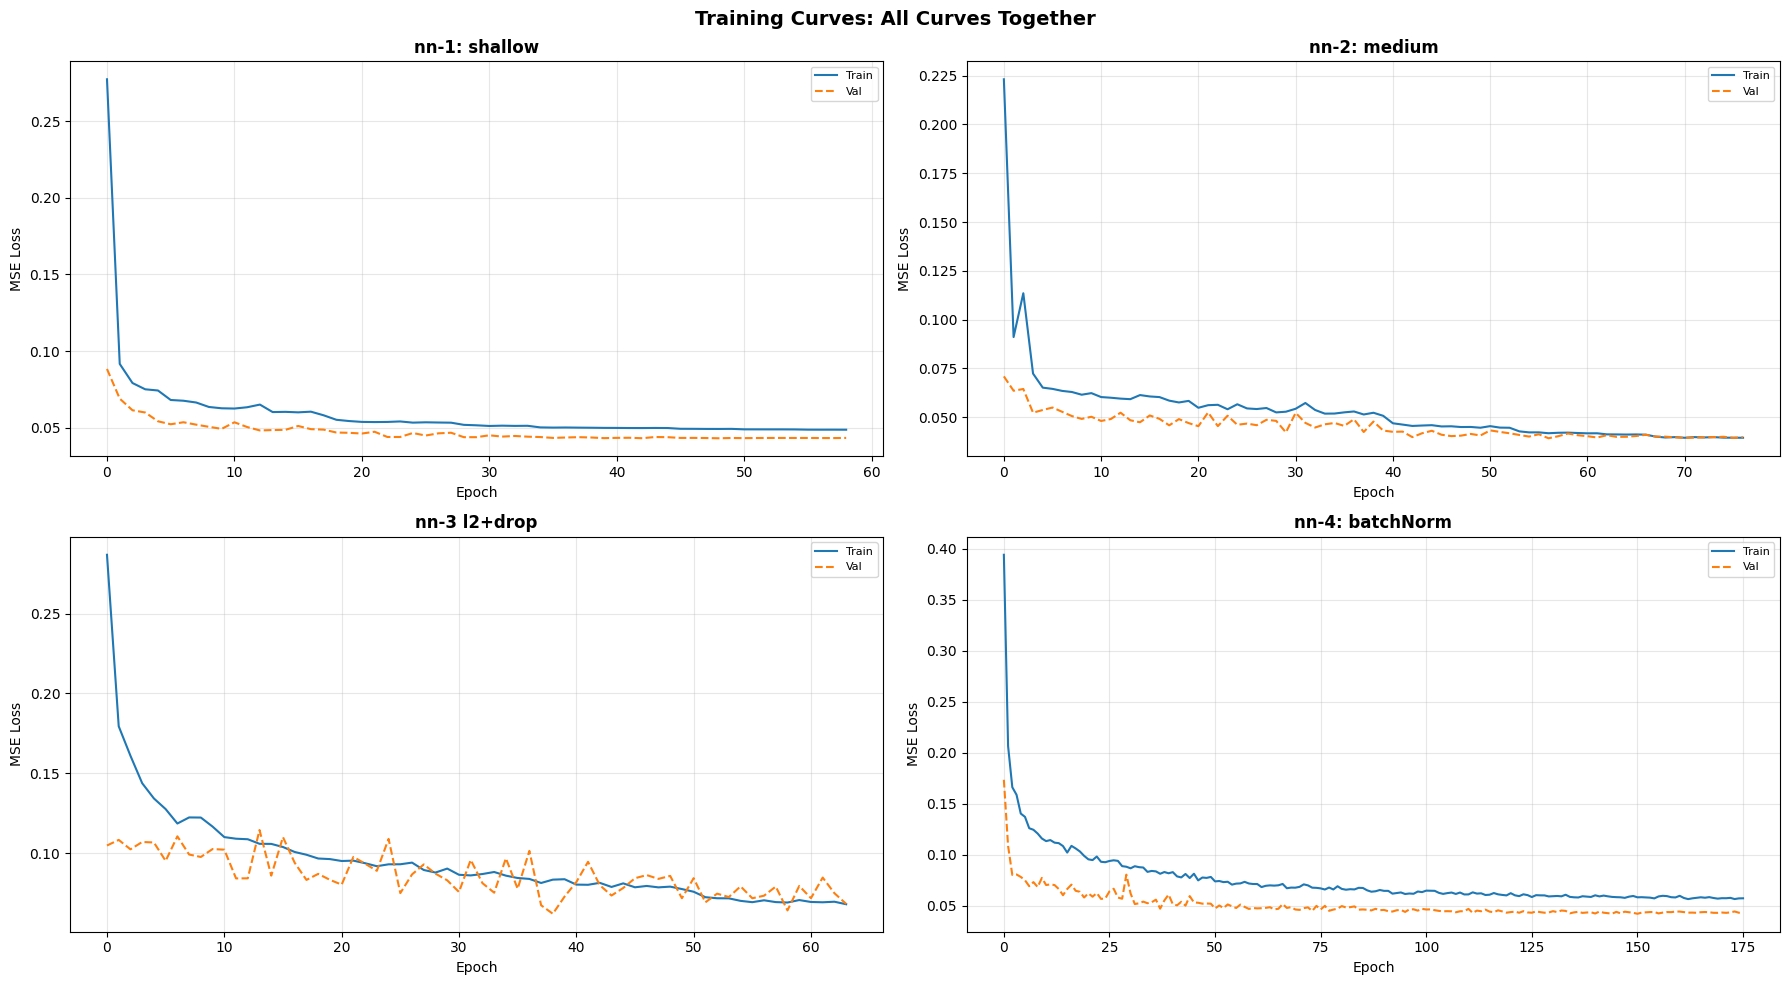

In [37]:
# Combining all training curves alltogether
nn_models = {
    'nn-1: shallow': history_nn1,
    'nn-2: medium':  history_nn2,
    'nn-3 l2+drop':    history_nn4,
    'nn-4: batchNorm':history_nn5,
}

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle('Training Curves: All Curves Together', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, (name, hist) in enumerate(nn_models.items()):
    ax = axes[i]
    ax.plot(hist.history['loss'],     label='Train', linewidth=1.5)
    ax.plot(hist.history['val_loss'], label='Val',
            linewidth=1.5, linestyle='--')
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The training curves show that all neural network architectures converge
successfully, with both training and validation losses decreasing and
stabilizing over time.

- **NN-2** achieves fast convergence with a low validation loss, representing
  a good balance between model capacity and generalization.

- **NN-3 (L2 + Dropout)** shows a characteristic pattern where training loss
  exceeds validation loss — this is expected behavior with Dropout, which
  randomly disables neurons during training, artificially inflating train loss.
  The model is not underfitting; rather, regularization is working as intended.

- **NN-4 (BatchNorm)** converges more slowly but reaches a competitive
  validation loss after ~150 epochs, suggesting that Batch Normalization
  stabilizes training at the cost of requiring more iterations.

Overall, the results indicate that increasing regularization and normalization
does not always yield faster convergence, but can improve training stability
and generalization on this tabular dataset.

In [38]:
# NN-7: Hyperparameter Search — different learning rates.
# This section is about experiments:

lr_candidates = [1e-2, 1e-3, 5e-4, 1e-4]
dropout_candidates = [0.2, 0.3, 0.4]

search_results = []

for lr in lr_candidates:
    for dp in dropout_candidates:
        def build_search_model(lr=lr, dp=dp):
            model = Sequential([
                Dense(256, input_shape=(N_FEATURES,)),
                BatchNormalization(),
                layers.Activation('relu'),
                Dropout(dp),
                Dense(128),
                BatchNormalization(),
                layers.Activation('relu'),
                Dropout(dp * 0.7),
                Dense(64, activation='relu'),
                Dense(1)
            ])
            model.compile(optimizer=Adam(lr), loss='mse')
            return model

        m = build_search_model(lr, dp)
        h = m.fit(
            X_train_s, y_train_nn,
            validation_data=(X_val_s, y_val_nn),
            epochs=150, batch_size=64,
            callbacks=[EarlyStopping(patience=15, restore_best_weights=True)],
            verbose=0
        )
        best_val_loss = min(h.history['val_loss'])
        search_results.append({'lr': lr, 'dropout': dp, 'val_loss': best_val_loss})
        print(f'  lr={lr:.0e}, dropout={dp} -> val_loss={best_val_loss:.6f}')

search_df = pd.DataFrame(search_results).sort_values('val_loss')
print(search_df.head(5).to_string(index=False))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  lr=1e-02, dropout=0.2 -> val_loss=0.046038
  lr=1e-02, dropout=0.3 -> val_loss=0.047271
  lr=1e-02, dropout=0.4 -> val_loss=0.048617
  lr=1e-03, dropout=0.2 -> val_loss=0.043965
  lr=1e-03, dropout=0.3 -> val_loss=0.048729
  lr=1e-03, dropout=0.4 -> val_loss=0.058111
  lr=5e-04, dropout=0.2 -> val_loss=0.041061
  lr=5e-04, dropout=0.3 -> val_loss=0.056172
  lr=5e-04, dropout=0.4 -> val_loss=0.058871
  lr=1e-04, dropout=0.2 -> val_loss=0.061587
  lr=1e-04, dropout=0.3 -> val_loss=0.063135
  lr=1e-04, dropout=0.4 -> val_loss=0.073332
    lr  dropout  val_loss
0.0005      0.2  0.041061
0.0010      0.2  0.043965
0.0100      0.2  0.046038
0.0100      0.3  0.047271
0.0100      0.4  0.048617


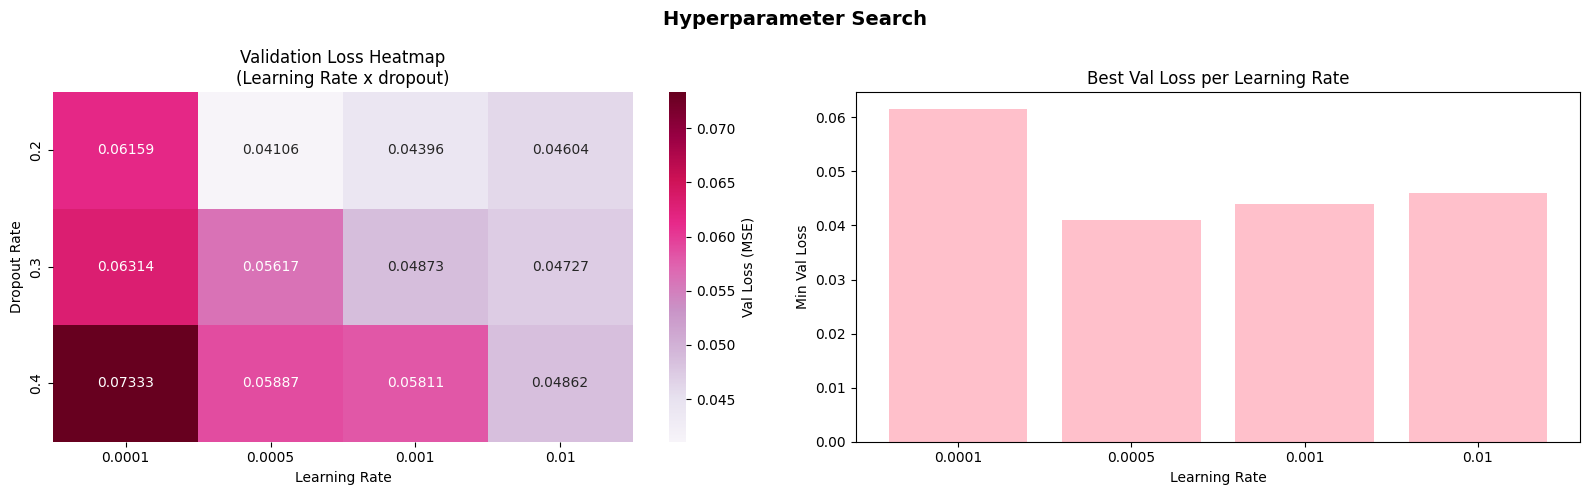

In [39]:
# Visualizing best params
pivot_hp = search_df.pivot(index='dropout', columns='lr', values='val_loss')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Hyperparameter Search', fontsize=14, fontweight='bold')

# Heatmap
sns.heatmap(pivot_hp, annot=True, fmt='.5f', cmap='PuRd',
            ax=axes[0], cbar_kws={'label': 'Val Loss (MSE)'})
axes[0].set_title('Validation Loss Heatmap\n(Learning Rate x dropout)')
axes[0].set_xlabel('Learning Rate')
axes[0].set_ylabel('Dropout Rate')

# best per learning rate -boxplot
best_per_lr = search_df.groupby('lr')['val_loss'].min().reset_index()
axes[1].bar([str(lr) for lr in best_per_lr['lr']],
            best_per_lr['val_loss'], color='pink')
axes[1].set_title('Best Val Loss per Learning Rate')
axes[1].set_xlabel('Learning Rate')
axes[1].set_ylabel('Min Val Loss')

plt.tight_layout()
plt.show()

best_hp = search_df.iloc[0]

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


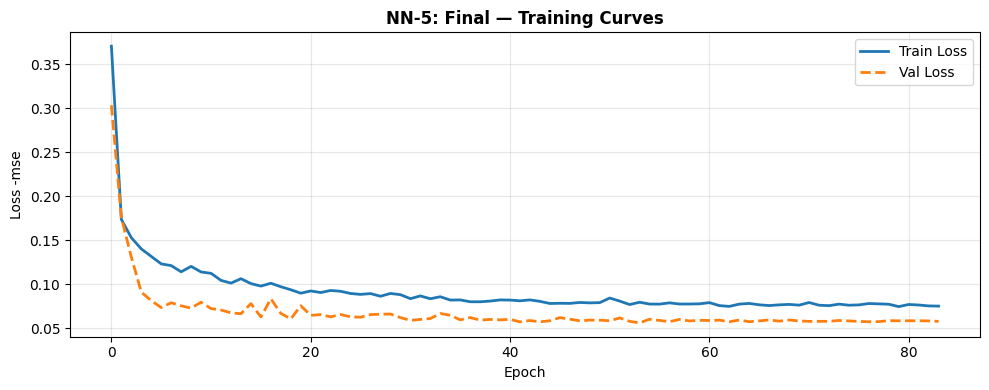

[NN-5: final Best NN]
  Test RMSE: 2942.57
  Test MAE:  1792.79
  Test R*R:   0.9299



In [40]:
# And finally - creating the best model


best_lr = float(best_hp['lr'])
best_dp = float(best_hp['dropout'])

X_full_nn = np.vstack([X_train_s, X_val_s])
y_full_nn = np.concatenate([y_train_nn, y_val_nn])

def build_final_nn(lr, dp):
    model = Sequential([
        Dense(256, input_shape=(N_FEATURES,),
              kernel_regularizer=regularizers.l2(1e-5)),
        BatchNormalization(),
        layers.Activation('relu'),
        Dropout(dp),
        Dense(128, kernel_regularizer=regularizers.l2(1e-5)),
        BatchNormalization(),
        layers.Activation('relu'),
        Dropout(dp * 0.7),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(lr), loss='mse', metrics=['mae'])
    return model

nn_final = build_final_nn(best_lr, best_dp)

#10% of full training
history_final = nn_final.fit(
    X_full_nn, y_full_nn,
    validation_split=0.1,
    epochs=500, batch_size=128,
    callbacks=[
        EarlyStopping(patience=30, restore_best_weights=True),
        ReduceLROnPlateau(factor=0.5, patience=10, min_lr=1e-6)
    ],
    verbose=0
)

plot_training_history(history_final, 'NN-5: Final')
r_final = evaluate_nn('NN-5: final Best NN', nn_final, X_test_s, y_test)


The final optimized Neural Network (NN-5) achieves R² = 0.9299 and
RMSE = 2942, which — while a strong result in absolute terms — falls
slightly short of XGBoost's results. This outcome is consistent with well-established findings in the
machine learning literature: tree-based ensemble methods (XGBoost,
Random Forest) tend to outperform neural networks on structured
tabular data, particularly when the dataset size is moderate. **Conclusion**: XGBoost remains the best-performing model for this
dataset.

In [41]:
# results from nn
summary_rows = []
for name, r in results.items():
    summary_rows.append({
        'Model': name,
        'Test RMSE': round(r['test_rmse'], 2),
        'Test MAE':  round(r['test_mae'],  2),
        'Test R*R':   round(r['test_r2'],   4),
        # 'CV RMSE':   round(r['cv_rmse_mean'], 2) if r['cv_rmse_mean'] else '-'
    })

summary_df = pd.DataFrame(summary_rows).sort_values('Test RMSE')

print(summary_df.to_string(index=False))

# Styled display
summary_df.style \
    .background_gradient(subset=['Test RMSE', 'Test MAE'], cmap='PuRd') \
    .background_gradient(subset=['Test R*R'], cmap='PuRd') \
    .format({'Test RMSE': '{:.2f}', 'Test MAE': '{:.2f}', 'Test R*R': '{:.4f}'}) \
    .set_caption('Model Performance on test set')

                         Model  Test RMSE  Test MAE  Test R*R
               XGBoost (tuned)    2312.61   1486.42    0.9567
      Random Forest (50 trees)    2430.75   1542.80    0.9522
     Random Forest (100 trees)    2433.92   1533.77    0.9521
       Random Forest 100 trees    2433.92   1533.77    0.9521
             XGBoost (default)    2440.98   1499.65    0.9518
     Random Forest (200 trees)    2457.46   1536.87    0.9511
               NN-2 Medium MLP    2580.99   1578.93    0.9461
     NN-4: BatchNorm + Dropout    2598.83   1584.43    0.9454
               nn1 shallow MLP    2753.48   1669.86    0.9387
            NN-3: L2 + Dropout    2819.28   1770.83    0.9357
       Random Forest 200 trees    2937.28   1658.03    0.9302
           NN-5: final Best NN    2942.57   1792.79    0.9299
       Decision Tree (default)    2998.09   1953.60    0.9273
Decision Tree with max_depth=8    3645.95   2284.91    0.8925
             Linear Regression    4175.67   2708.89    0.8589
        

,Model,Test RMSE,Test MAE,Test R*R
10,XGBoost (tuned),2312.61,1486.42,0.9567
6,Random Forest (50 trees),2430.75,1542.80,0.9522
7,Random Forest (100 trees),2433.92,1533.77,0.9521
4,Random Forest 100 trees,2433.92,1533.77,0.9521
9,XGBoost (default),2440.98,1499.65,0.9518
8,Random Forest (200 trees),2457.46,1536.87,0.9511
12,NN-2 Medium MLP,2580.99,1578.93,0.9461
14,NN-4: BatchNorm + Dropout,2598.83,1584.43,0.9454
11,nn1 shallow MLP,2753.48,1669.86,0.9387
13,NN-3: L2 + Dropout,2819.28,1770.83,0.9357


The results show that the medium-sized neural network (NN-2) and the Batch Normalization model (NN-4) achieved the best performance among all tested neural network architectures. In contrast, more heavily regularized models, such as NN-3 (L2 + Dropout), performed significantly worse.

Interestingly, the final tuned model (NN-5), despite incorporating hyperparameter optimization and a more complex architecture, did not outperform simpler models. This suggests that increasing architectural complexity and applying regularization techniques does not necessarily improve performance for tabular data.

However, when compared to classical machine learning models, neural networks do not achieve the best overall results. Ensemble methods, particularly XGBoost, outperform all neural network configurations, achieving the lowest RMSE (2312.61) and highest R*R (0.957).


# 📦 Section 7 - Cross - Validation Analysis

Cross-validation is crucial for model evaluation. It:
- Reduces variance of the performance estimate
- Detects overfitting
- Provides a reliable metric for model selection



Cross-validation results (RMSE):

Decision Tree       : 3560.58 ± 636.37
Random Forest       : 2773.63 ± 558.30
XGBoost (tuned)     : 2666.87 ± 561.56


/tmp/ipykernel_523/1590772117.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


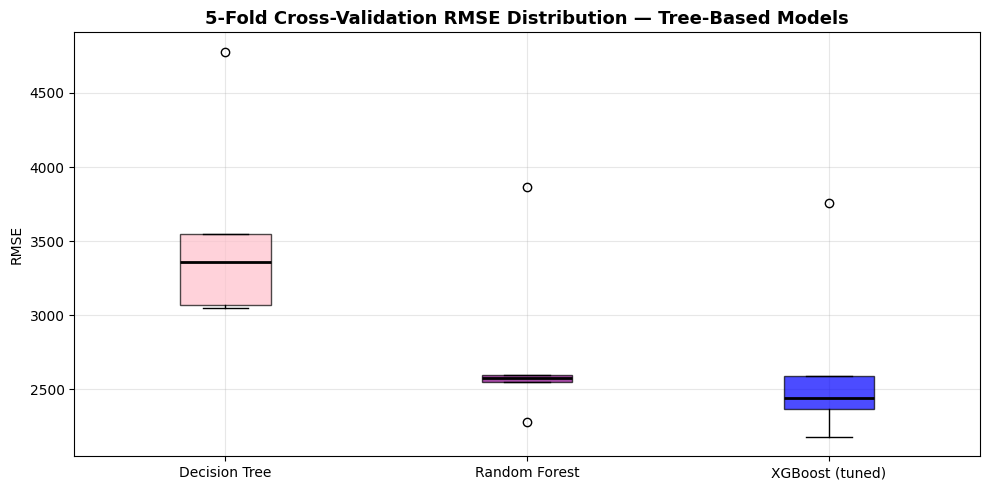

In [45]:
from sklearn.model_selection import KFold, cross_val_score
import matplotlib.pyplot as plt
import numpy as np

cv_models = {
    'Decision Tree': DecisionTreeRegressor(random_state=42),

    'Random Forest': RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    'XGBoost (tuned)': xgb.XGBRegressor(
        objective='reg:squarederror',
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        verbosity=0
    ),
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_data = {}

print("Cross-validation results (RMSE):\n")

for name, model in cv_models.items():
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=kf,
        scoring='neg_root_mean_squared_error'
    )

    rmse_scores = -scores
    cv_data[name] = rmse_scores

    print(f'{name:20s}: {rmse_scores.mean():.2f} ± {rmse_scores.std():.2f}')

fig, ax = plt.subplots(figsize=(10, 5))

box = ax.boxplot(
    cv_data.values(),
    labels=cv_data.keys(),
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2)
)

colors = ['pink', 'purple', 'blue']  # tree, RF, XGB
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title('5-Fold Cross-Validation RMSE Distribution — Tree-Based Models',
             fontsize=13, fontweight='bold')
ax.set_ylabel('RMSE')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 📦 Section : FINAL

In [43]:
print(f'   Total models trained: {len(results)}')
print(f'   Best model: {summary_df.iloc[0]["Model"]}')
print(f'   Best RMSE:  {summary_df.iloc[0]["Test RMSE"]}')
print(f'   Best R*R:    {summary_df.iloc[0]["Test R*R"]}')

   Total models trained: 16
   Best model: XGBoost (tuned)
   Best RMSE:  2312.61
   Best R*R:    0.9567
